In [1]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_classic.schema import Document

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_classic.tools.retriever import create_retriever_tool

In [2]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)
embedding = OpenAIEmbeddings()



In [3]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]
    retrieved_doc : list[Document] = []
    
def make_retriever_tool_from_text(file_path, tool_name, desc):
    loader = PyMuPDFLoader(file_path=file_path)
    docs = loader.load()
    
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)
    chunks = text_splitter.split_documents(docs)
    
    vectorstore = FAISS.from_documents(chunks, embedding)
    retriever = vectorstore.as_retriever()
    
    def tool_retriever():
        retriever_tool = create_retriever_tool(
            retriever,
            tool_name,
            desc
        )
    
        return retriever_tool
    
    retriever_tool = tool_retriever()
    return retriever_tool



In [4]:
nilai_farhan_tool = make_retriever_tool_from_text(
    "pdf/farhan.pdf",
    "SikadFarhan",
    "Mencari informasi nilai untuk mahasiswa farhan dan IPK farhan atau hasil akhir perkuliahan farhan"
)

nilai_ratu_tool = make_retriever_tool_from_text(
    "pdf/ratu.pdf",
    "SikadRatu",
    "Mencari informasi nilai untuk mahasiswa Ratu dan IPK Ratu atau hasil akhir perkuliahan Ratu"
)

tools = [nilai_farhan_tool, nilai_ratu_tool]

In [5]:
llm_with_tools = model.bind_tools(tools)

In [6]:
def tool_calling_llm(state:State) -> State:
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

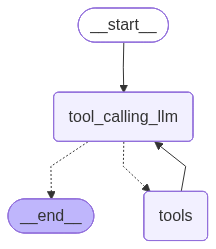

In [7]:
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

memory = MemorySaver()
builder_graph = builder.compile(checkpointer=memory)
display(Image(builder_graph.get_graph().draw_mermaid_png()))

In [8]:
def make_config(thread_id):
    return {"configurable" : {"thread_id" : thread_id}}


config = make_config(1)
query = f"Bisakah kamu bandingkan nilai farhan dan nilai ratu dan berikan kesimppulan singkatnya ya"
response = builder_graph.invoke({"messages" : HumanMessage(content=query)}, config = config)

response["messages"][-1].content

'**Perbandingan singkat nilai akademik Farhan vs Ratu**\n\n| Mahasiswa | IPK | SKS yang diperoleh | Rata‑rata nilai (berdasarkan skor yang tercatat) |\n|-----------|-----|--------------------|---------------------------------------------------|\n| **Farhan Kamil Hermansyah** | **3,97** | 50 | **≈\u202f87** (nilai A pada Jaringan Syaraf Tiruan; nilai ≈\u202f86,8 pada Sistem Operasi) |\n| **Ratu Qolbu Maziah** | **3,08** | 46 | **≈\u202f76** (nilai AB pada sebagian besar mata kuliah; satu mata kuliah (Pemrograman Web) mendapat nilai A, namun ada mata kuliah dengan nilai rendah ≈\u202f56) |\n\n### Kesimpulan singkat\n- **Farhan** memiliki IPK yang jauh lebih tinggi (3,97) dan rata‑rata nilai yang lebih baik (≈\u202f87) dibandingkan **Ratu** (IPK\u202f3,08, rata‑rata nilai\u202f≈\u202f76).  \n- Dari data yang tersedia, Farhan menunjukkan performa akademik yang lebih konsisten dan unggul di semua mata kuliah yang tercatat, sementara Ratu memiliki variasi nilai yang lebih besar, termasuk beb

In [9]:
query = f"buatkan jangan dalam bentuk tabel"
response = builder_graph.invoke({"messages" : HumanMessage(content=query)}, config = config)

In [10]:
response["messages"][-1].content

'Berikut perbandingan singkat nilai akademik Farhan dan Ratu:\n\n- **IPK**: Farhan mencatat IPK 3,97, sedangkan Ratu memiliki IPK 3,08. Selisih hampir satu poin penuh, menandakan Farhan berada di atas rata‑rata yang sangat baik, sementara Ratu berada di kisaran menengah‑atas.\n\n- **SKS yang sudah ditempuh**: Farhan telah mengumpulkan 50 SKS, sementara Ratu 46 SKS. Jadi Farhan sedikit lebih maju dalam hal beban studi yang telah diselesaikan.\n\n- **Rata‑rata nilai** (berdasarkan skor yang terlihat pada lembar nilai):\n  - Farhan memperoleh nilai A pada mata kuliah Jaringan Syaraf Tiruan dan nilai sekitar 86‑87 pada Sistem Operasi, menghasilkan rata‑rata nilai kira‑kira 87.\n  - Ratu menunjukkan variasi nilai yang lebih besar. Ia mendapatkan nilai A pada Pemrograman Web, tetapi banyak mata kuliah lain berada di kisaran AB (sekitar 70‑80) dan ada satu mata kuliah (Sistem Operasi) dengan nilai sangat rendah (sekitar 56). Rata‑rata nilai Ratu kira‑kira 76.\n\n- **Kesimpulan**: Dari segi pr

In [11]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Bisakah kamu bandingkan nilai farhan dan nilai ratu dan berikan kesimppulan singkatnya ya
================================== Ai Message ==================================
Tool Calls:
  SikadFarhan (fc_0dc2bef2-4d38-4327-866d-14fb2d929250)
 Call ID: fc_0dc2bef2-4d38-4327-866d-14fb2d929250
  Args:
    query: nilai Farhan
================================= Tool Message =================================
Name: SikadFarhan

** AKTIVITAS KULIAH MAHASISWA **
Semester
:
GANJIL 2025/2026
Tanggal : 27-01-2026
Program Studi :
INFORMATIKA
Jam : 14:01
N.I.M
:
15-2024-150 FARHAN KAMIL HERMANSYAH          Telpon:  62-895-1233-6363           E-mail : farmiljobs@gmail.com
Form : AKT298C
Batas Studi
:
GENAP 2030/2031          Jumlah Cuti: 0          IPK: 3.97          SKS Peroleh:  50
Hal : 1
Dosen Wali
:
11565 YUSUP MIFTAHUDDIN
No
Kode
Matakuliah
SKS
Kelas
Jenis
SC1
SC2
SC3
SC4
SC5
SC6
SC7
SC8
Nilai
Hari
Jam
Status

009 IFB

In [12]:
query = f"jadi menurut kamu farhan gimana? apaakah dia bisa bertahan dengan ipk segitu terus?"
response = builder_graph.invoke({"messages" : HumanMessage(content=query)}, config = config)

In [13]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Bisakah kamu bandingkan nilai farhan dan nilai ratu dan berikan kesimppulan singkatnya ya
================================== Ai Message ==================================
Tool Calls:
  SikadFarhan (fc_0dc2bef2-4d38-4327-866d-14fb2d929250)
 Call ID: fc_0dc2bef2-4d38-4327-866d-14fb2d929250
  Args:
    query: nilai Farhan
================================= Tool Message =================================
Name: SikadFarhan

** AKTIVITAS KULIAH MAHASISWA **
Semester
:
GANJIL 2025/2026
Tanggal : 27-01-2026
Program Studi :
INFORMATIKA
Jam : 14:01
N.I.M
:
15-2024-150 FARHAN KAMIL HERMANSYAH          Telpon:  62-895-1233-6363           E-mail : farmiljobs@gmail.com
Form : AKT298C
Batas Studi
:
GENAP 2030/2031          Jumlah Cuti: 0          IPK: 3.97          SKS Peroleh:  50
Hal : 1
Dosen Wali
:
11565 YUSUP MIFTAHUDDIN
No
Kode
Matakuliah
SKS
Kelas
Jenis
SC1
SC2
SC3
SC4
SC5
SC6
SC7
SC8
Nilai
Hari
Jam
Status

009 IFB

NameError: name 'messages' is not defined

In [15]:
response

{'messages': [HumanMessage(content='Bisakah kamu bandingkan nilai farhan dan nilai ratu dan berikan kesimppulan singkatnya ya', additional_kwargs={}, response_metadata={}, id='d189be90-1201-4bc1-9f8a-d23e0f85fb9e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Bisakah kamu bandingkan nilai farhan dan nilai ratu dan berikan kesimppulan singkatnya ya". Need to retrieve data about Farhan and Ratu using provided functions. Likely need to query both. Use SikadFarhan and SikadRatu. Query likely "nilai Farhan" and "nilai Ratu". Then compare. We\'ll call both.', 'tool_calls': [{'index': 0, 'id': 'fc_0dc2bef2-4d38-4327-866d-14fb2d929250', 'function': {'arguments': '{"query":"nilai Farhan"}', 'name': 'SikadFarhan'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019bff84-7ae1-7a51-8389-42ba45a